# Part 2: Results Analysis & Discussion
Notebook này trình bày kết quả phân tích và so sánh mô hình trên bộ dữ liệu thực.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# add root path
project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from part1.ols_implementation import ols_fit, coef_inference, vif
from part1.ridge_lasso import ridge_fit

from data_pipeline import DataPipeline, load_data, train_test_split
from model_comparison import run_diagnostics, train_models, hyperparameter_tuning, comparison_table, plot_coefficients
from advanced_methods import kernel_ridge_fit

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. EDA khảo sát và chẩn đoán

### 2.1. Tổng quan Dữ liệu gốc

In [2]:
data_path = Path("data/melb_data.csv")
df = load_data(data_path)
print("=== Xem trước các dòng đầu của bộ dữ liệu gốc ===")
display(df.head())

print("=== Khảo sát sơ bộ tổng thể ===")
display(df.info())

=== Xem trước các dòng đầu của bộ dữ liệu gốc ===


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


=== Khảo sát sơ bộ tổng thể ===
<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null

None

Schema xác nhận `Price` là target, dữ liệu gồm numeric và categorical;

### 2.2. Phân tách Dữ liệu thô

In [3]:
X_train_raw, X_test_raw = train_test_split(df, test_size=0.3, random_state=42)

split_summary = pd.DataFrame(
    {
        "split": ["X_train_raw", "X_test_raw"],
        "rows": [len(X_train_raw), len(X_test_raw)],
        "pct": [round(len(X_train_raw) / len(df) * 100, 2), round(len(X_test_raw) / len(df) * 100, 2)],
    }
)
display(split_summary)

,split,rows,pct
0,X_train_raw,9506,70.0
1,X_test_raw,4074,30.0


Split được thực hiện trên DataFrame thô. Các thống kê dùng để chọn preprocessing chính thức lấy từ `X_train_raw`.


### 2.3. Thống kê mô tả: mean, median, std, min, max, quartiles

In [4]:
numeric_raw_columns = X_train_raw.select_dtypes(include=np.number).columns.tolist()
raw_descriptive_stats = pd.DataFrame(
    {
        "mean": X_train_raw[numeric_raw_columns].mean(),
        "median": X_train_raw[numeric_raw_columns].median(),
        "std": X_train_raw[numeric_raw_columns].std(),
        "min": X_train_raw[numeric_raw_columns].min(),
        "q1": X_train_raw[numeric_raw_columns].quantile(0.25),
        "q2": X_train_raw[numeric_raw_columns].quantile(0.50),
        "q3": X_train_raw[numeric_raw_columns].quantile(0.75),
        "max": X_train_raw[numeric_raw_columns].max(),
    }
).round(2)
display(raw_descriptive_stats)

,mean,median,std,min,q1,q2,q3,max
Rooms,2.94,3.0,0.95,1.00,2.00,3.0,3.00,10.00
Price,1076128.42,905000.0,637183.57,131000.00,650000.00,905000.0,1330000.00,8000000.00
Distance,10.12,9.2,5.90,0.00,6.10,9.2,13.00,48.10
Postcode,3106.09,3084.0,93.11,3000.00,3046.00,3084.0,3148.00,3977.00
Bedroom2,2.93,3.0,0.97,0.00,2.00,3.0,3.00,20.00
Bathroom,1.53,1.0,0.69,0.00,1.00,1.0,2.00,8.00
Car,1.60,2.0,0.95,0.00,1.00,2.0,2.00,10.00
Landsize,541.64,446.0,1642.07,0.00,179.00,446.0,651.00,76000.00
BuildingArea,154.42,126.0,646.59,0.00,92.00,126.0,172.00,44515.00
YearBuilt,1964.41,1970.0,37.74,1196.00,1940.00,1970.0,1999.00,2018.00


Bảng thống kê raw dùng để nhìn biên độ và độ lệch giữa mean/median.


In [5]:
duplicate_rows = int(X_train_raw.duplicated().sum())
duplicate_check = pd.DataFrame(
    {
        "metric": ["duplicate_rows", "duplicate_pct"],
        "value": [duplicate_rows, round(duplicate_rows / len(X_train_raw) * 100, 2)],
    }
)
display(duplicate_check)

,metric,value
0,duplicate_rows,0.0
1,duplicate_pct,0.0


Duplicate check chỉ kiểm tra dòng trùng hoàn toàn trên raw dataset; pipeline baseline không drop row ở bước EDA.


### 2.4. Phân tích Missing Values

In [6]:
train_missing_summary = pd.DataFrame(
    {
        "missing_count": X_train_raw.isna().sum(),
        "missing_pct": X_train_raw.isna().mean().mul(100).round(2),
    }
).query("missing_count > 0").sort_values("missing_pct", ascending=False)
train_missing_summary

,missing_count,missing_pct
BuildingArea,4557,47.94
YearBuilt,3815,40.13
CouncilArea,953,10.03
Car,42,0.44


`BuildingArea` và `YearBuilt` thiếu nhiều nhất, nên dùng median train-only thay vì mean để giảm ảnh hưởng của phân phối lệch và outlier.


### 2.5. Phát hiện Outliers & Invalid Values

In [7]:
train_invalid_summary = pd.DataFrame(
    [
        {"check": "Price <= 0", "rows": int((X_train_raw["Price"] <= 0).sum())},
        {"check": "Rooms == 0", "rows": int((X_train_raw["Rooms"] == 0).sum())},
        {"check": "Landsize <= 0", "rows": int((X_train_raw["Landsize"] <= 0).sum())},
        {"check": "BuildingArea <= 0", "rows": int((X_train_raw["BuildingArea"] <= 0).sum())},
        {"check": "YearBuilt < 1800", "rows": int((X_train_raw["YearBuilt"] < 1800).sum())},
    ]
)
train_invalid_summary

,check,rows
0,Price <= 0,0
1,Rooms == 0,0
2,Landsize <= 0,1353
3,BuildingArea <= 0,13
4,YearBuilt < 1800,1


Các điều kiện invalid này có ý nghĩa theo miền dữ liệu nên được repair trong pipeline; outlier giá trị lớn không bị drop tự động.


In [8]:
outlier_columns = ["Price", "Landsize", "BuildingArea", "YearBuilt"]
train_outlier_quantiles = X_train_raw[outlier_columns].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T.round(2)
train_outlier_quantiles

,0.01,0.05,0.50,0.95,0.99
Price,300050.00,407125.0,905000.0,2300000.0,3359500.00
Landsize,0.00,0.0,446.0,1002.5,2976.85
BuildingArea,6.92,52.4,126.0,291.0,446.60
YearBuilt,1880.00,1900.0,1970.0,2012.0,2015.00


In [9]:
iqr_rows = []
for column in outlier_columns:
    series = X_train_raw[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((series < lower_bound) | (series > upper_bound)).sum())
    iqr_rows.append(
        {
            "column": column,
            "iqr_outliers": outlier_count,
            "outlier_pct_iqr": round(outlier_count / len(series) * 100, 2),
            "iqr_lower_bound": round(lower_bound, 2),
            "iqr_upper_bound": round(upper_bound, 2),
        }
    )

train_iqr_outlier_summary = pd.DataFrame(iqr_rows).sort_values("outlier_pct_iqr", ascending=False)
train_iqr_outlier_summary

,column,iqr_outliers,outlier_pct_iqr,iqr_lower_bound,iqr_upper_bound
2,BuildingArea,244,4.93,-28.0,292.0
0,Price,442,4.65,-370000.0,2350000.0
1,Landsize,269,2.83,-529.0,1359.0
3,YearBuilt,6,0.11,1851.5,2087.5


Quantile và IQR tập trung vào `Price`, `Landsize`, `BuildingArea`, `YearBuilt` vì đây là các biến ảnh hưởng trực tiếp tới imputation, scaling và feature engineering. Không dùng z-score vì các biến này lệch phải mạnh.


### 2.6. Phân tích Đơn biến (Univariate Analysis)

#### a. Biểu đồ phân phối (Histogram) & Độ lệch (Skewness)

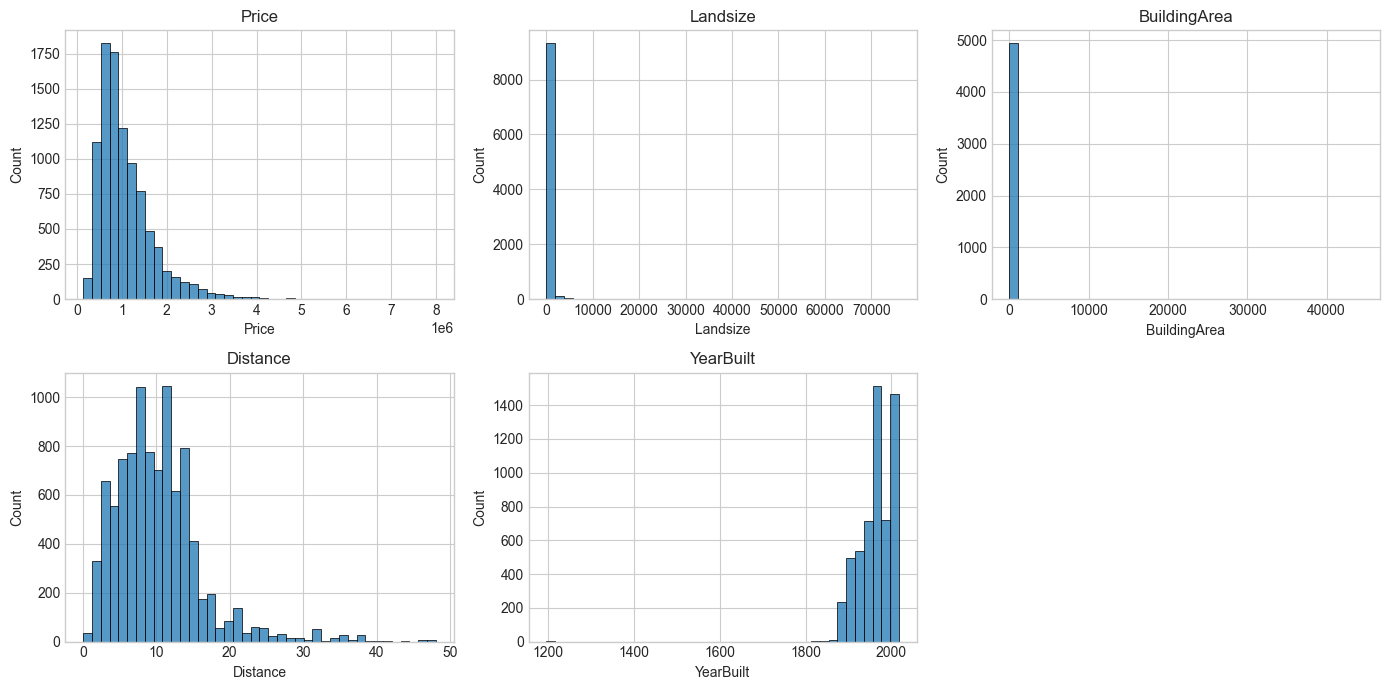

In [10]:
plot_columns = ["Price", "Landsize", "BuildingArea", "Distance", "YearBuilt"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, plot_columns):
    sns.histplot(data=X_train_raw, x=column, bins=40, ax=ax)
    ax.set_title(column)

for ax in axes[len(plot_columns):]:
    ax.set_visible(False)

plt.tight_layout()

`Price`, `Landsize`, `BuildingArea` lệch phải nên các bước fill và fallback ưu tiên median.


In [11]:
numeric_columns = [
    "Price",
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Distance",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Propertycount",
]

numeric_profile = X_train_raw[numeric_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
numeric_profile["skew"] = X_train_raw[numeric_columns].skew(numeric_only=True)
numeric_profile.round(2)


,count,mean,std,min,1%,5%,50%,95%,99%,max,skew
Price,9506.0,1076128.42,637183.57,131000.0,300050.00,407125.0,905000.0,2300000.0,3359500.00,8000000.0,2.19
Rooms,9506.0,2.94,0.95,1.0,1.00,2.0,3.0,4.0,5.00,10.0,0.35
Bedroom2,9506.0,2.93,0.97,0.0,1.00,1.0,3.0,4.0,5.00,20.0,0.92
Bathroom,9506.0,1.53,0.69,0.0,1.00,1.0,1.0,3.0,3.95,8.0,1.32
Car,9464.0,1.60,0.95,0.0,0.00,0.0,2.0,3.0,4.00,10.0,1.34
Distance,9506.0,10.12,5.90,0.0,1.60,2.6,9.2,20.6,32.27,48.1,1.67
Landsize,9506.0,541.64,1642.07,0.0,0.00,0.0,446.0,1002.5,2976.85,76000.0,28.97
BuildingArea,4949.0,154.42,646.59,0.0,6.92,52.4,126.0,291.0,446.60,44515.0,65.56
YearBuilt,5691.0,1964.41,37.74,1196.0,1880.00,1900.0,1970.0,2012.0,2015.00,2018.0,-1.94
Propertycount,9506.0,7490.50,4385.61,249.0,962.00,2211.0,6567.0,14949.0,21650.00,21650.0,1.08


`Landsize`, `BuildingArea`, `Distance` có scale lệch mạnh so với biến đếm; scaling sau preprocessing giúp ma trận OLS ổn định hơn.


#### b. Trực quan hóa Outlier (Boxplot)

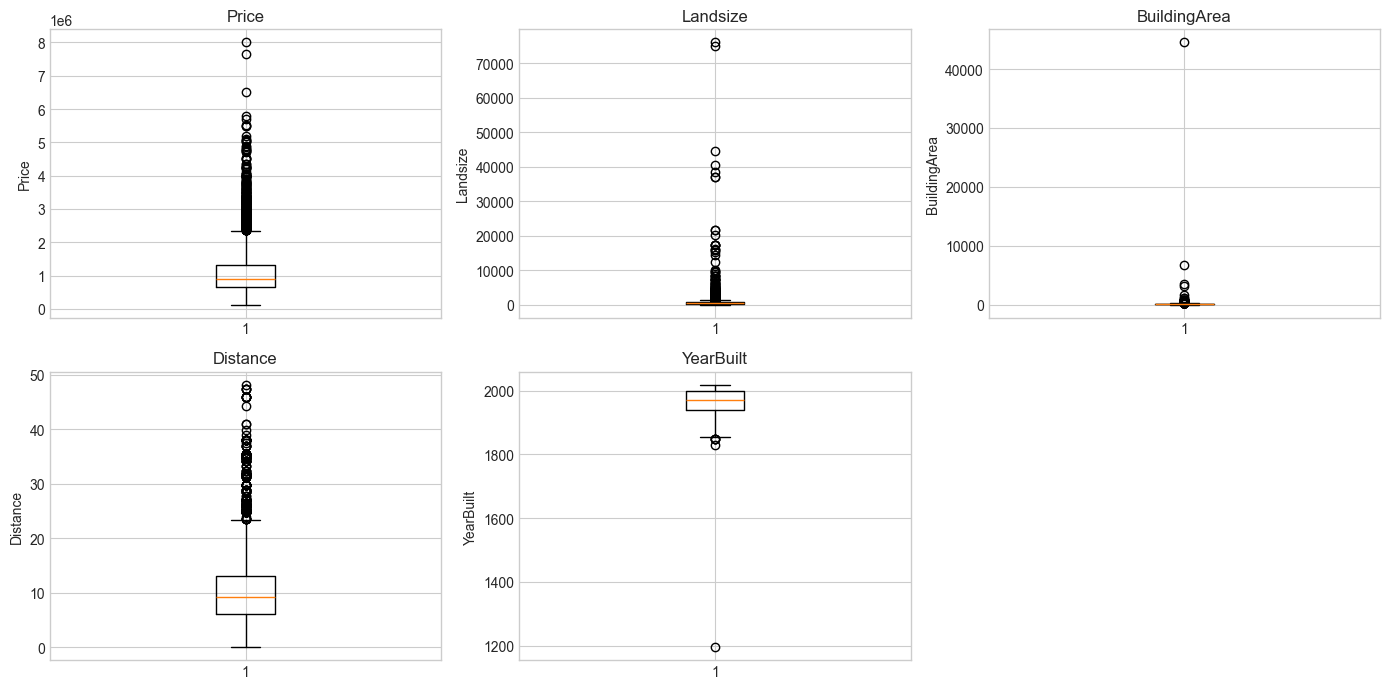

In [12]:
plot_columns = ["Price", "Landsize", "BuildingArea", "Distance", "YearBuilt"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, plot_columns):
    ax.boxplot(X_train_raw[column].dropna(), vert=True)
    ax.set_title(column)
    ax.set_ylabel(column)

for ax in axes[len(plot_columns):]:
    ax.set_visible(False)

plt.tight_layout()

Boxplot dùng để nhận diện đuôi dài và điểm cực trị của các biến chính; pipeline chỉ repair invalid values, không loại bỏ nhà giá cao hoặc đất lớn hợp lệ.


#### c. Khảo sát Biến phân loại (Categorical Variables)

In [13]:
categorical_columns = ["Type", "Regionname", "Method", "CouncilArea"]
categorical_summary = pd.DataFrame(
    {
        "column": categorical_columns,
        "unique_values": [X_train_raw[column].nunique(dropna=True) for column in categorical_columns],
        "missing_pct": [round(X_train_raw[column].isna().mean() * 100, 2) for column in categorical_columns],
        "top_value": [X_train_raw[column].mode(dropna=True).iloc[0] for column in categorical_columns],
    }
)
categorical_summary

,column,unique_values,missing_pct,top_value
0,Type,3,0.00,h
1,Regionname,8,0.00,Southern Metropolitan
2,Method,5,0.00,S
3,CouncilArea,33,10.03,Moreland


In [14]:
type_price = X_train_raw.groupby("Type")["Price"].agg(["count", "median", "mean"]).round(0)
region_price = (
    X_train_raw.groupby("Regionname")["Price"]
    .agg(["count", "median"])
    .sort_values("median", ascending=False)
    .round(0)
)

type_price, region_price


(      count     median       mean
 Type                             
 h      6614  1080500.0  1243525.0
 t       767   841000.0   928520.0
 u      2125   565000.0   608391.0,
                             count     median
 Regionname                                  
 Southern Metropolitan        3280  1250000.0
 Eastern Metropolitan         1035  1005000.0
 South-Eastern Metropolitan    314   850000.0
 Northern Metropolitan        2771   810000.0
 Western Metropolitan         2012   799000.0
 Eastern Victoria               38   653000.0
 Northern Victoria              32   537500.0
 Western Victoria               24   400000.0)

Với baseline OLS, `Type` và `Regionname` đủ gọn để one-hot mà vẫn giữ tín hiệu loại nhà và khu vực. Bảng median price theo nhóm giải thích vì sao hai cột này được giữ.


### 2.7. Phân tích Đa biến (Multivariate Analysis)

#### a. Ma trận tương quan (Correlation Heatmap)

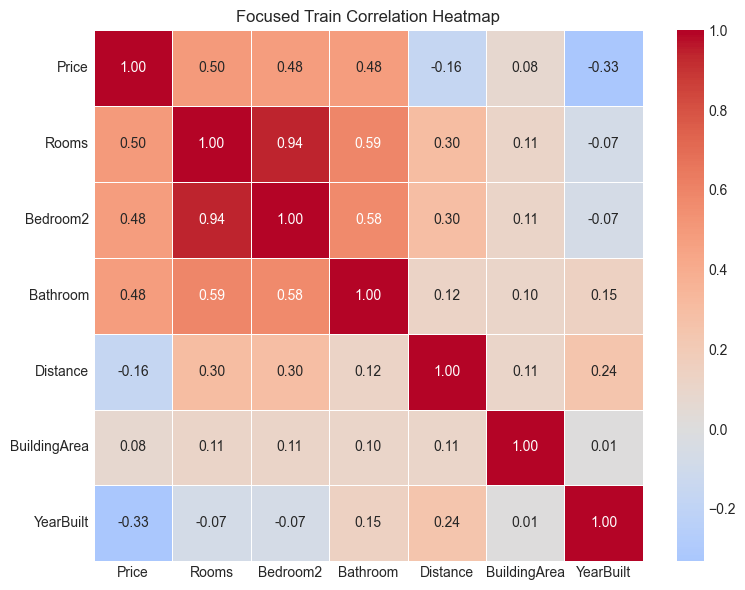

In [15]:
corr_columns = ["Price", "Rooms", "Bedroom2", "Bathroom", "Distance", "BuildingArea", "YearBuilt"]
focused_corr = X_train_raw[corr_columns].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(focused_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Focused Train Correlation Heatmap")
plt.tight_layout()


Heatmap tập trung vào các biến có rủi ro đa cộng tuyến hoặc liên quan trực tiếp tới `Price`. `Bedroom2` chồng lấp với `Rooms`, còn `YearBuilt` được chuyển thành `Age` rồi drop trong pipeline.


In [16]:
relationship_columns = ["Price", "Rooms", "Bedroom2", "Bathroom", "Car", "Distance", "BuildingArea", "YearBuilt"]
relationship_summary = X_train_raw[relationship_columns].corr(numeric_only=True)[["Price", "Rooms"]].round(3)
relationship_summary


,Price,Rooms
Price,1.000,0.499
Rooms,0.499,1.000
Bedroom2,0.480,0.941
Bathroom,0.481,0.593
Car,0.238,0.402
Distance,-0.164,0.298
BuildingArea,0.079,0.112
YearBuilt,-0.331,-0.075


Bảng tương quan nhỏ giữ lại phần số cụ thể cho quyết định drop `Bedroom2` và không tạo `OtherRooms`, tránh phụ thuộc tuyến tính không cần thiết cho OLS.


#### b. Phân tích Không gian (Geo-Spatial Analysis)

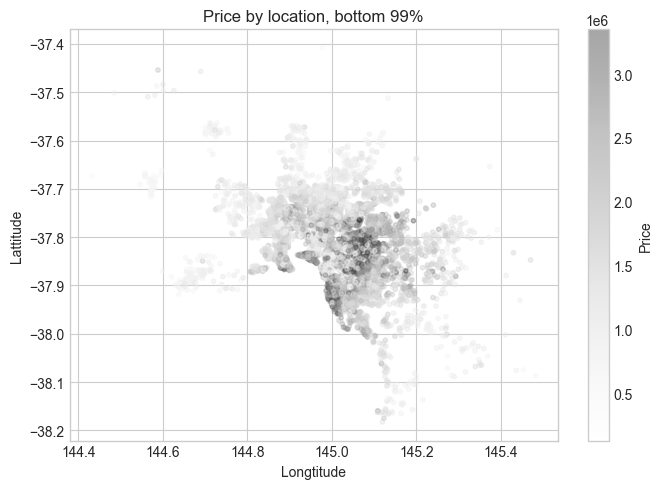

In [17]:
geo_df = X_train_raw[X_train_raw["Price"] < X_train_raw["Price"].quantile(0.99)]
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    geo_df["Longtitude"],
    geo_df["Lattitude"],
    c=geo_df["Price"],
    alpha=0.35,
    s=10,
)
plt.xlabel("Longtitude")
plt.ylabel("Lattitude")
plt.title("Price by location, bottom 99%")
plt.colorbar(scatter, label="Price")
plt.tight_layout()


### 2.8. Khám phá Đặc trưng mới (Feature Engineering Preview)

In [18]:
feature_preview = X_train_raw[["Rooms", "BuildingArea", "Landsize", "YearBuilt", "Date"]].copy()
feature_preview["SaleYear"] = pd.to_datetime(feature_preview["Date"], dayfirst=True, errors="coerce").dt.year
feature_preview["Age"] = feature_preview["SaleYear"] - feature_preview["YearBuilt"]
feature_preview["BuildingArea_per_Room"] = feature_preview["BuildingArea"] / feature_preview["Rooms"].replace(0, np.nan)
feature_preview["BuildingCoverage"] = feature_preview["BuildingArea"] / feature_preview["Landsize"].replace(0, np.nan)
feature_preview[["Age", "BuildingArea_per_Room", "BuildingCoverage"]].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Age,5691.0,52.08,37.69,-2.0,18.00,47.00,76.00,821.0
BuildingArea_per_Room,4949.0,50.03,132.68,0.0,37.33,44.00,53.00,8903.0
BuildingCoverage,4214.0,0.44,1.21,0.0,0.22,0.34,0.54,62.0


`Age` dùng năm bán từ `Date`, không dùng mốc năm hiện tại. Ratio features giữ ở mức đơn giản và được fallback bằng median train nếu phát sinh NaN/inf.


## Phase 1: Vòng lặp xử lí dữ liệu gốc

### 1. Tiền xử lý dữ liệu
Dựa trên kết quả EDA, ta sẽ đưa dữ liệu vào Pipeline. Tuy nhiên, để đảm bảo ma trận hoàn toàn sạch đa cộng tuyến, ta thực hiện vòng lặp **Xây dựng -> Chẩn đoán VIF -> Tinh chỉnh** trong phase 1.

In [19]:
# TODO: Preprocessing pipeline
# Khởi tạo và chạy pipeline trên tập train thô
current_drop = []
pipeline_loop = DataPipeline(drop_columns=current_drop)
X_train_temp, y_train_temp = pipeline_loop.fit_transform(X_train_raw)

### 2. Chẩn đoán sơ khởi

In [20]:
vif_steps = [
    {
        "step": "Step 0 - Before filtering",
        "drop_columns": [],
        "reason": "Baseline feature set before applying DA's VIF recommendations.",
    },
    {
        "step": "Step 1 - Drop BuildingArea_per_Room only",
        "drop_columns": ["BuildingArea_per_Room"],
        "reason": "Remove the derived ratio that is highly collinear with BuildingArea.",
    },
    {
        "step": "Step 2 - Drop Bedroom2 only",
        "drop_columns": ["Bedroom2"],
        "reason": "Remove the secondary room-count feature while keeping Rooms.",
    },
    {
        "step": "Step 3 - Final selected features",
        "drop_columns": ["BuildingArea_per_Room", "Bedroom2"],
        "reason": "Apply both feature-selection decisions used by the final modeling pipeline.",
    },
]

vif_tables = {}
vif_step_summary = []

for config in vif_steps:
    pipeline_step = DataPipeline(drop_columns=config["drop_columns"])
    X_step, y_step = pipeline_step.fit_transform(X_train_raw)

    diagnostics_step = run_diagnostics(
        X_train_raw=X_step,
        y_train=y_step,
        feature_names=pipeline_step.encoded_columns,
        custom_ols_func=ols_fit,
        custom_vif_func=vif,
        custom_inference_func=coef_inference,
    )

    vif_table = diagnostics_step["VIF"].sort_values(by="VIF_Score", ascending=False).copy()
    vif_table = vif_table[["Feature", "VIF_Score"]].rename(columns={"VIF_Score": "VIF"})
    vif_tables[config["step"]] = vif_table

    vif_step_summary.append(
        {
            "step": config["step"],
            "drop_columns": ", ".join(config["drop_columns"]) if config["drop_columns"] else "None",
            "feature_count": X_step.shape[1],
            "max_vif": round(float(vif_table["VIF"].max()), 4),
            "rooms_vif": round(float(vif_table.loc[vif_table["Feature"] == "Rooms", "VIF"].iloc[0]), 4) if "Rooms" in vif_table["Feature"].values else None,
            "reason": config["reason"],
        }
    )

display(pd.DataFrame(vif_step_summary))

for step_name, table in vif_tables.items():
    print(step_name)
    display(table.head(10))

,step,drop_columns,feature_count,max_vif,rooms_vif,reason
0,Step 0 - Before filtering,None,25,36.2312,10.5036,Baseline feature set before applying DA's VIF ...
1,Step 1 - Drop BuildingArea_per_Room only,BuildingArea_per_Room,24,9.5964,9.5964,Remove the derived ratio that is highly collin...
2,Step 2 - Drop Bedroom2 only,Bedroom2,24,36.2300,3.2616,Remove the secondary room-count feature while ...
3,Step 3 - Final selected features,"BuildingArea_per_Room, Bedroom2",23,6.6528,2.3863,Apply both feature-selection decisions used by...


Step 0 - Before filtering


,Feature,VIF
0,BuildingArea,36.231201
1,BuildingArea_per_Room,35.926535
2,Rooms,10.503640
3,Bedroom2,8.878682
4,Regionname_Western Metropolitan,6.654466
5,Regionname_Northern Metropolitan,4.843023
6,Regionname_Southern Metropolitan,4.335510
7,Longtitude,4.018864
8,Lattitude,2.638210
9,YearBuilt_missing,2.504087


Step 1 - Drop BuildingArea_per_Room only


,Feature,VIF
0,Rooms,9.596417
1,Bedroom2,8.878329
2,Regionname_Western Metropolitan,6.654352
3,Regionname_Northern Metropolitan,4.842887
4,Regionname_Southern Metropolitan,4.335472
5,Longtitude,4.018519
6,Lattitude,2.638171
7,YearBuilt_missing,2.504083
8,BuildingArea_missing,2.476841
9,Type_u,2.290272


Step 2 - Drop Bedroom2 only


,Feature,VIF
0,BuildingArea,36.230045
1,BuildingArea_per_Room,35.925106
2,Regionname_Western Metropolitan,6.652885
3,Regionname_Northern Metropolitan,4.842521
4,Regionname_Southern Metropolitan,4.335230
5,Longtitude,4.018793
6,Rooms,3.261552
7,Lattitude,2.638077
8,YearBuilt_missing,2.503808
9,BuildingArea_missing,2.495096


Step 3 - Final selected features


,Feature,VIF
0,Regionname_Western Metropolitan,6.652766
1,Regionname_Northern Metropolitan,4.842382
2,Regionname_Southern Metropolitan,4.335191
3,Longtitude,4.018449
4,Lattitude,2.638039
5,YearBuilt_missing,2.503804
6,BuildingArea_missing,2.476369
7,Rooms,2.386328
8,Type_u,2.288093
9,Distance,2.156270


### Sync point: Đánh giá & quyết định
* **Nhận xét của Data Analyst:** `BuildingArea_per_Room` có VIF rất cao và gần như tuyến tính với `BuildingArea`; `Bedroom2` làm tăng đa cộng tuyến với `Rooms`.
* **Quyết định chọn biến:** Nhóm giữ lại biến gốc có ý nghĩa chính (`BuildingArea`, `Rooms`) và loại `BuildingArea_per_Room`, `Bedroom2` ở tầng pipeline để tạo tập đặc trưng selected.

## Phase 2: Huấn luyện & Đánh giá mô hình

### 1. Tiền xử lí dữ liệu cho mô hình

In [21]:
# Khởi tạo Pipeline mới nhận lệnh loại bỏ cột từ Data Analyst
final_drop_list = ["BuildingArea_per_Room", "Bedroom2"]

# 1. Pipeline Baseline (Cấu hình rỗng [] - Giữ nguyên cột gốc)
X_train_df = X_train_raw.copy()
X_test_df = X_test_raw.copy()

pipeline_baseline = DataPipeline(drop_columns=[])
X_train_baseline, y_train_baseline = pipeline_baseline.fit_transform(X_train_df)
X_test_baseline, y_test_baseline = pipeline_baseline.transform(X_test_df)

# 2. Pipeline Tối ưu (Cấu hình final_drop_list - Đã lọc sạch đa cộng tuyến)
pipeline_best = DataPipeline(drop_columns=final_drop_list)
X_train_best, y_train = pipeline_best.fit_transform(X_train_df)
X_test_best, y_test = pipeline_best.transform(X_test_df)

# 3. Đóng gói Metadata bàn giao (Contract 1)
metadata = {
    "feature_names": pipeline_best.feature_names,
    "target_name": pipeline_best.target_name,
    "drop_columns": pipeline_best.drop_columns,
    "engineered_features": [
        "Age",
        "BuildingCoverage",
        "BuildingArea_missing",
        "YearBuilt_missing",
        "Landsize_zero_or_missing",
    ],
    "encoding_strategy": "one_hot_drop_first",
    "imputation_strategy": "MV2_column_median_train_only",
    "scaling_method": "standardize",
}

display(
    pd.DataFrame(
        {
            "artifact": [
                "X_train_clean",
                "X_test_clean",
                "y_train",
                "y_test",
                "features",
            ],
            "shape": [
                X_train_best.shape,
                X_test_best.shape,
                y_train.shape,
                y_test.shape,
                len(metadata["feature_names"]),
            ],
        }
    )
)

,artifact,shape
0,X_train_clean,"(9506, 23)"
1,X_test_clean,"(4074, 23)"
2,y_train,"(9506,)"
3,y_test,"(4074,)"
4,features,23


### 2. Đánh giá dữ liệu cho mô hình

#### 2.1. Feature Contract Validation

In [22]:
expected_engineered_features = metadata["engineered_features"]
X_train_df = pd.DataFrame(X_train_best, columns=metadata["feature_names"])
X_test_df = pd.DataFrame(X_test_best, columns=metadata["feature_names"])

feature_contract_check = pd.DataFrame(
    {
        "feature": expected_engineered_features,
        "exists_in_output": [
            feature in metadata["feature_names"]
            for feature in expected_engineered_features
        ],
        "train_has_no_nan": [
            (
                bool(not X_train_df[feature].isna().any())
                if feature in X_train_df.columns
                else False
            )
            for feature in expected_engineered_features
        ],
        "test_has_no_nan": [
            (
                bool(not X_test_df[feature].isna().any())
                if feature in X_test_df.columns
                else False
            )
            for feature in expected_engineered_features
        ],
        "train_is_finite": [
            (
                bool(np.isfinite(X_train_df[feature]).all())
                if feature in X_train_df.columns
                else False
            )
            for feature in expected_engineered_features
        ],
        "test_is_finite": [
            (
                bool(np.isfinite(X_test_df[feature]).all())
                if feature in X_test_df.columns
                else False
            )
            for feature in expected_engineered_features
        ],
    }
)

failed_feature_contract = feature_contract_check.loc[
    ~feature_contract_check.drop(columns=["feature"]).all(axis=1)
]
assert failed_feature_contract.empty, failed_feature_contract.to_string(index=False)
feature_contract_check

,feature,exists_in_output,train_has_no_nan,test_has_no_nan,train_is_finite,test_is_finite
0,Age,True,True,True,True,True
1,BuildingCoverage,True,True,True,True,True
2,BuildingArea_missing,True,True,True,True,True
3,YearBuilt_missing,True,True,True,True,True
4,Landsize_zero_or_missing,True,True,True,True,True


#### 2.2. OLS matrix rank check


In [23]:
X_design = np.c_[np.ones(X_train_best.shape[0]), X_train_best]
design_rank = np.linalg.matrix_rank(X_design)
condition_number = np.linalg.cond(X_design)

rank_check = pd.DataFrame(
    {
        "metric": ["n_columns", "matrix_rank", "full_rank", "condition_number"],
        "value": [
            X_design.shape[1],
            design_rank,
            bool(design_rank == X_design.shape[1]),
            float(condition_number),
        ],
    }
)

assert design_rank == X_design.shape[1]
assert condition_number < 1e10
rank_check

,metric,value
0,n_columns,24
1,matrix_rank,24
2,full_rank,True
3,condition_number,6.758866


#### 2.3. Handoff validation


In [24]:
handoff_checks = pd.DataFrame(
    [
        {"check": "X_train_best has no NaN", "passed": bool(not np.isnan(X_train_best).any())},
        {"check": "X_test_best has no NaN", "passed": bool(not np.isnan(X_test_best).any())},
        {"check": "X_train_best is finite", "passed": bool(np.isfinite(X_train_best).all())},
        {"check": "X_test_best is finite", "passed": bool(np.isfinite(X_test_best).all())},
        {"check": "same feature count", "passed": bool(X_train_best.shape[1] == X_test_best.shape[1])},
        {"check": "metadata feature count", "passed": bool(len(metadata["feature_names"]) == X_train_best.shape[1])},
        {"check": "y_train has no NaN", "passed": bool(not np.isnan(y_train).any())},
        {"check": "y_test has no NaN", "passed": bool(not np.isnan(y_test).any())},
        {"check": "y_train is finite", "passed": bool(np.isfinite(y_train).all())},
        {"check": "y_test is finite", "passed": bool(np.isfinite(y_test).all())},
        {"check": "y_train is positive", "passed": bool((y_train > 0).all())},
        {"check": "y_test is positive", "passed": bool((y_test > 0).all())},
        {"check": "X_train_best/y_train aligned", "passed": bool(X_train_best.shape[0] == len(y_train))},
        {"check": "X_test_best/y_test aligned", "passed": bool(X_test_best.shape[0] == len(y_test))},
    ]
)

assert handoff_checks["passed"].all()
handoff_checks


,check,passed
0,X_train_best has no NaN,True
1,X_test_best has no NaN,True
2,X_train_best is finite,True
3,X_test_best is finite,True
4,same feature count,True
5,metadata feature count,True
6,y_train has no NaN,True
7,y_test has no NaN,True
8,y_train is finite,True
9,y_test is finite,True


### 3. Tìm Siêu Tham Số Ridge Qua K-Fold CV

In [25]:
# ML Modeler tiến hành dò tìm thông số phạt tốt nhất trên tập X_train_best
lambda_grid = [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]

best_params_ridge, best_cv_rmse, cv_scores = hyperparameter_tuning(
    X_train=X_train_best.tolist(),
    y_train=y_train.tolist(),
    param_grid={"alpha": lambda_grid},
    k=5,
)
best_lambda_ridge = best_params_ridge["alpha"]
print(f"Hệ số phạt tối ưu cho Ridge tìm được: \u03bb = {best_lambda_ridge} | CV RMSE = {best_cv_rmse:,.2f}")

Hệ số phạt tối ưu cho Ridge tìm được: λ = 100.0 | CV RMSE = 413,887.77


### 3. Huấn luyện mô hình

In [26]:
# 6. Chạy các mô hình theo rubric: OLS baseline, OLS selected, Ridge, Kernel, Bayesian
baseline_results = train_models(
    X_train=X_train_baseline,
    y_train=y_train_baseline,
    X_test=X_test_baseline,
    y_test=y_test_baseline,
    custom_ols_func=ols_fit,
    include_ridge=False,
    include_kernel=False,
    include_bayesian=False,
)

selected_results = train_models(
    X_train=X_train_best,
    y_train=y_train,
    X_test=X_test_best,
    y_test=y_test,
    custom_ols_func=ols_fit,
    custom_ridge_func=ridge_fit,
    ridge_param_grid={"alpha": [best_lambda_ridge]},
    kernel_params={"alpha": 1.0, "kernel": "rbf", "gamma": 0.1},
    kernel_sample_size=1000,
)

results_dict = {
    "OLS_baseline": baseline_results["OLS"],
    "OLS_selected": selected_results["OLS"],
    "Ridge": selected_results["Ridge"],
    "Kernel_Ridge": selected_results["Kernel_Ridge"],
    "Bayesian_Linear": selected_results["Bayesian_Linear"],
}

### 4. DataFrame

In [27]:
# ML Modeler chuyển giao bảng xếp hạng hiệu năng tổng hợp cho Data Analyst
df_leaderboard = comparison_table(results_dict)
df_leaderboard

,Rank,Model,MAE,RMSE,R2,Train_RMSE,Train_R2,Source,Best_Params
0,1,OLS_baseline,271914.526737,419892.936449,0.575209,393991.460584,0.617624,part1,{}
1,2,Bayesian_Linear,272136.947130,419983.728868,0.575026,394126.006772,0.617363,advanced_methods,"{'prior_precision': 1e-06, 'noise_precision': ..."
2,3,OLS_selected,272136.947147,419983.728869,0.575026,394126.006772,0.617363,part1,{}
3,4,Ridge,270623.634835,420129.568544,0.574730,394318.536024,0.616989,part1,"{'lambda': 100.0, 'cv_rmse': 413887.7716205819}"
4,5,Kernel_Ridge,250201.647574,432856.996862,0.548574,400274.449976,0.605332,advanced_methods,"{'alpha': 1.0, 'lambda_kernel': 1.0, 'kernel':..."


## Phase 3: Đánh giá phần dư và trực quan hóa
* **Mục tiêu:** Vẽ biểu đồ chẩn đoán sức khỏe phần dư của mô hình vô địch, trực quan hóa mức độ quan trọng của đặc trưng nhằm viết báo cáo Typst thực tế.

,best_model
0,OLS_baseline


,test,lm_statistic,p_value,df,statistic
0,Breusch-Pagan,729.632146,8.014755e-138,25,NaN
1,Jarque-Bera (Custom Math),NaN,0.000000e+00,2,105943.984136


,Feature,VIF
0,Regionname_Western Metropolitan,6.652766
1,Regionname_Northern Metropolitan,4.842382
2,Regionname_Southern Metropolitan,4.335191
3,Longtitude,4.018449
4,Lattitude,2.638039
5,YearBuilt_missing,2.503804
6,BuildingArea_missing,2.476369
7,Rooms,2.386328
8,Type_u,2.288093
9,Distance,2.156270


,residual
count,9.506000e+03
mean,3.879694e-11
std,3.940122e+05
min,-1.886393e+06
25%,-2.266003e+05
50%,-4.868274e+04
75%,1.570721e+05
max,5.321549e+06


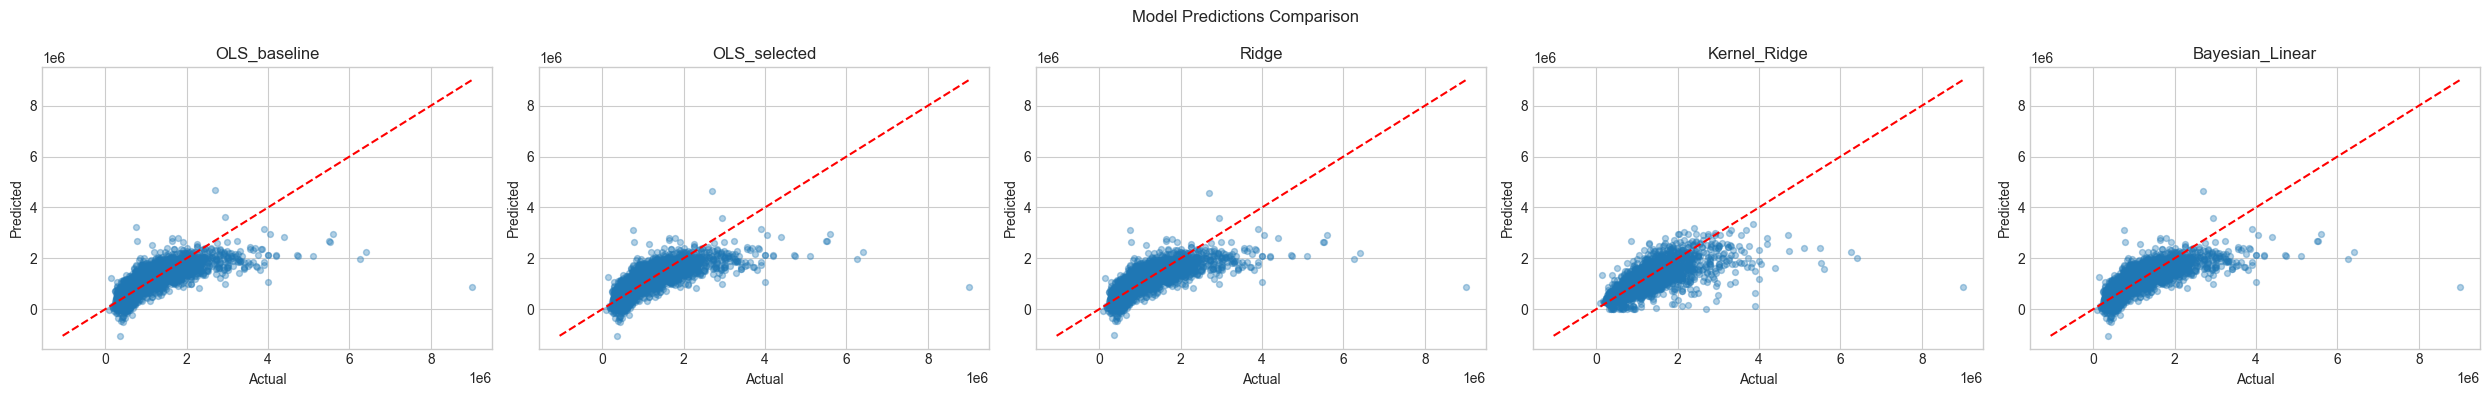

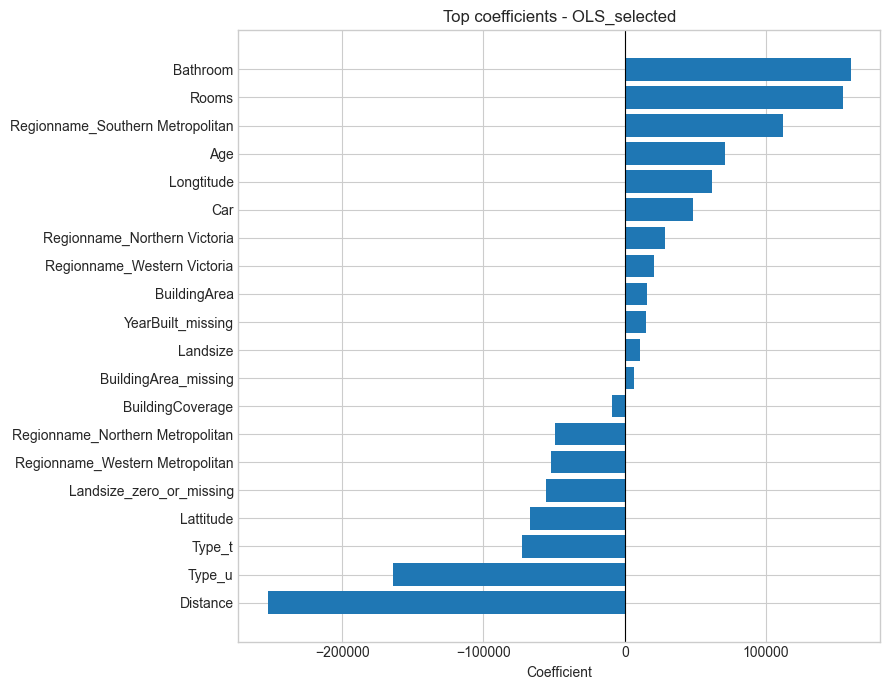

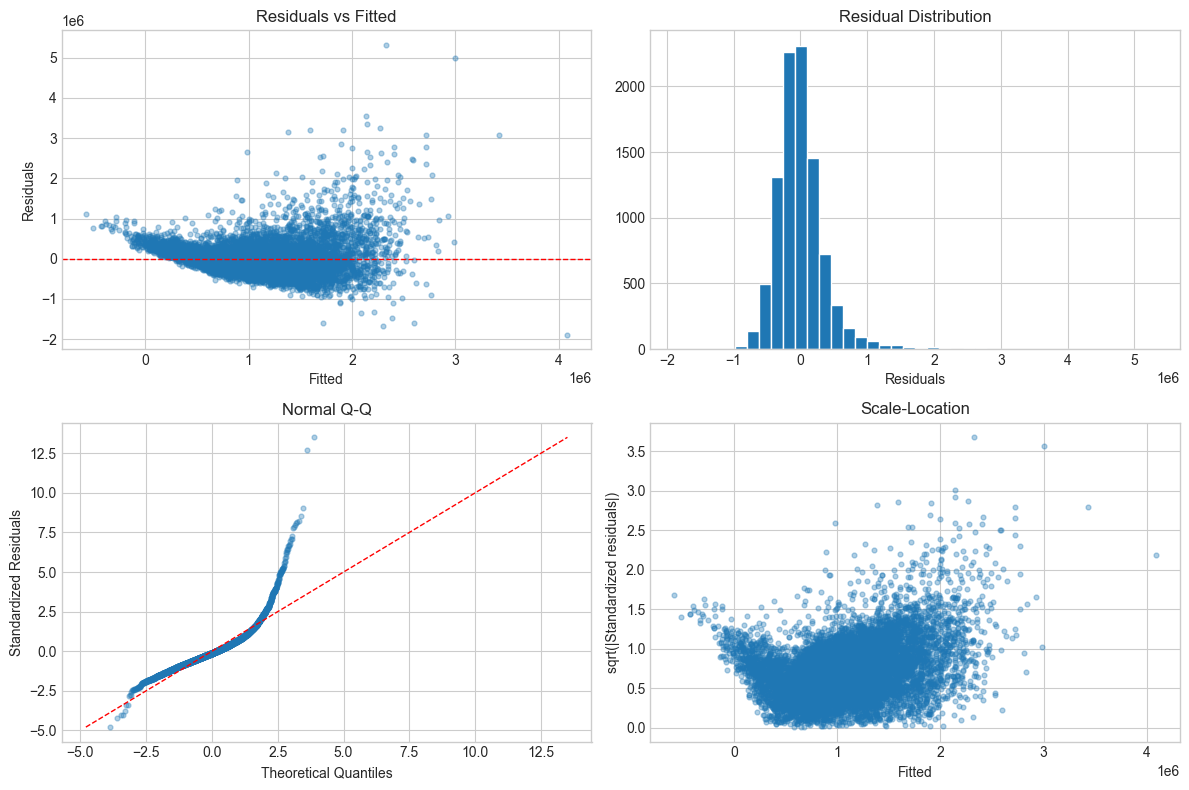

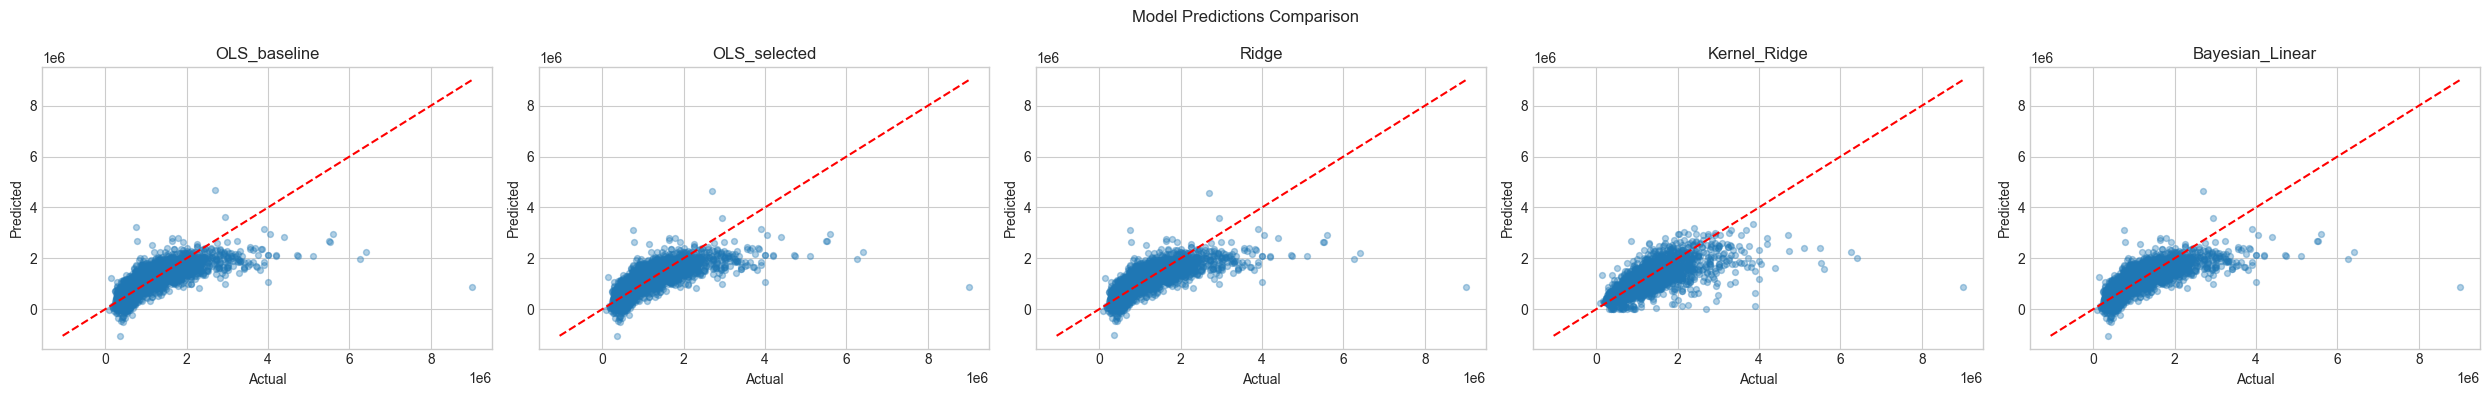

In [28]:
# 1. Vẽ hệ số của OLS selected để giải thích feature importance sau chuẩn hóa
plot_coefficients({"OLS_selected": results_dict["OLS_selected"]}, metadata["feature_names"])

# 2. Trích xuất phần dư của mô hình tốt nhất để phân tích kiểm định Gauss-Markov
from statistics import NormalDist
from model_comparison import evaluate_gauss_markov_assumptions, plot_predictions

best_model_key = comparison_table(results_dict).iloc[0]["Model"]
best_train_predictions = results_dict[best_model_key]["predictions_train"]

if best_model_key == "OLS_baseline":
    X_diag = X_train_baseline
    y_diag = y_train_baseline
    feature_names_diag = pipeline_baseline.feature_names
else:
    X_diag = X_train_best
    y_diag = y_train
    feature_names_diag = metadata["feature_names"]

best_residuals = [yt - yp for yt, yp in zip(y_diag.tolist(), best_train_predictions)]
gm_metrics = evaluate_gauss_markov_assumptions(X_diag, best_residuals, feature_names_diag)

selected_train_predictions = results_dict["OLS_selected"]["predictions_train"]
selected_residuals = [yt - yp for yt, yp in zip(y_train.tolist(), selected_train_predictions)]
selected_gm_metrics = evaluate_gauss_markov_assumptions(X_train_best, selected_residuals, metadata["feature_names"])

diagnostics_summary = pd.DataFrame(
    [
        {"test": "Breusch-Pagan", **gm_metrics["breusch_pagan"]},
        {"test": gm_metrics["normality"]["test"], "statistic": gm_metrics["normality"]["statistic"], "p_value": gm_metrics["normality"]["p_value"], "df": 2},
    ]
)
residual_summary = pd.Series(best_residuals).describe().to_frame("residual")

display(pd.DataFrame({"best_model": [best_model_key]}))
display(diagnostics_summary)
selected_vif_display = selected_gm_metrics["VIF"].sort_values(by="VIF_Score", ascending=False)
selected_vif_display = selected_vif_display[["Feature", "VIF_Score"]].rename(columns={"VIF_Score": "VIF"})
display(selected_vif_display.head(10))
display(residual_summary)

# 3. Bốn biểu đồ diagnostic cho phần dư của best model
fitted_values = list(best_train_predictions)
residual_values = list(best_residuals)
resid_mean = float(np.mean(residual_values))
resid_std = float(np.std(residual_values, ddof=1)) if len(residual_values) > 1 else 1.0
std_residuals = [(r - resid_mean) / resid_std for r in residual_values]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].scatter(fitted_values, residual_values, alpha=0.35, s=12)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted")
axes[0].set_ylabel("Residuals")

axes[1].hist(residual_values, bins=40, edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residuals")

sorted_residuals = sorted(std_residuals)
n_resid = len(sorted_residuals)
normal = NormalDist()
theoretical_q = [normal.inv_cdf((i - 0.5) / n_resid) for i in range(1, n_resid + 1)]
axes[2].scatter(theoretical_q, sorted_residuals, alpha=0.35, s=12)
qq_min = min(min(theoretical_q), min(sorted_residuals))
qq_max = max(max(theoretical_q), max(sorted_residuals))
axes[2].plot([qq_min, qq_max], [qq_min, qq_max], color="red", linestyle="--", linewidth=1)
axes[2].set_title("Normal Q-Q")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Standardized Residuals")

axes[3].scatter(fitted_values, np.sqrt(np.abs(std_residuals)), alpha=0.35, s=12)
axes[3].set_title("Scale-Location")
axes[3].set_xlabel("Fitted")
axes[3].set_ylabel("sqrt(|Standardized residuals|)")

plt.tight_layout()

plot_predictions(y_test, results_dict)

## Phase 4: Biện luận & Tổng kết báo cáo

1. **Mức độ đáp ứng yêu cầu mô hình:** Notebook đã so sánh `OLS_baseline`, `OLS_selected`, `Ridge`, `Kernel_Ridge` và `Bayesian_Linear`; trong đó `OLS_selected` là mô hình OLS chọn biến sau khi loại feature theo VIF.
2. **Diễn giải ranking:** Kết luận cuối cùng phải dựa trên `df_leaderboard`, không giả định Ridge luôn thắng OLS. Nếu `OLS_selected`/`OLS_baseline` đứng đầu, điều đó cho thấy regularization chưa cải thiện RMSE trên test set với cấu hình hiện tại; Ridge vẫn hữu ích vì giảm nhạy cảm hệ số khi có đa cộng tuyến.
3. **Đa cộng tuyến:** Việc loại `BuildingArea_per_Room` và `Bedroom2` giữ lại các biến sơ cấp (`BuildingArea`, `Rooms`), giúp mô hình selected dễ diễn giải hơn và giảm rủi ro ma trận thiết kế gần suy biến.
4. **Residual diagnostics:** Breusch-Pagan, Jarque-Bera, VIF sau selection và bốn biểu đồ residual được dùng để nhận xét giả định Gauss-Markov; nếu p-value nhỏ, cần ghi rõ dữ liệu nhà đất có heteroscedasticity/đuôi lệch nên inference tuyến tính cần thận trọng.
5. **Ý nghĩa thực tế:** Các hệ số sau chuẩn hóa chỉ phản ánh tương quan có điều kiện trong dữ liệu Melbourne; không diễn giải như quan hệ nhân quả.